# EURUSD Trading Strategy Assignment

## Data Mining and Algorithmic Trading

---

**Authors:**  
- Tayebeh Oveisi Fardoye  
- Sara Eghlidi  
- Alejandro Arzola de Leon  
- Hadi Shahparvari  

**Date:** January 2026

---

## Assignment Overview

### Part 1: Data Mining 
- Download 1-year EUR/USD 1-minute data (Nov 2024 - Oct 2025)
- Select 60 trading days for strategy mining
- Test 5 trading strategies: SMA Crossover, Momentum, RSI Trend, Mean Reversion, Breakout
- Evaluate using Sharpe Ratio, Maximum Drawdown, and Annualized Return
- Validate best strategy with 9+ months out-of-sample testing

### Part 2: Server Deployment 
- Implement live trading algorithm on server
- Connect to IB Gateway during trading hours
- Disconnect outside trading hours
- Deploy as systemd service

---

## Results Summary

| Metric | In-Sample (60 days) | Out-of-Sample (9 months) |
|--------|---------------------|--------------------------|
| **Best Strategy** | Momentum | Momentum |
| **Sharpe Ratio** | 5.98 | -1.14 |
| **Total Return** | +10.35% | -8.28% |
| **Max Drawdown** | -2.22% | -14.36% |
| **Time in Market** | 100% | 100% |

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import os

In [2]:
# === STEP 1: IMPORTS AND DATA LOADING ===

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Load Data
filename = 'EURUSD_1min_data.csv'
df = pd.read_csv(filename, index_col=0, parse_dates=True)
df = df.sort_index()

# 2. Filter for Assignment Period (Nov 1, 2024 - Oct 31, 2025)
df = df.loc['2024-11-01':'2025-10-31'].copy()

# 3. Basic Data Info
print("=" * 50)
print("STEP 1: DATA LOADED SUCCESSFULLY")
print("=" * 50)
print(f"Total Rows:        {len(df):,}")
print(f"Date Range:        {df.index.min()} to {df.index.max()}")
print(f"Columns:           {list(df.columns)}")
print(f"Total Trading Days: {df.index.normalize().nunique()}")
print("=" * 50)
print("\nFirst 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())

STEP 1: DATA LOADED SUCCESSFULLY
Total Rows:        368,535
Date Range:        2024-11-01 00:00:00 to 2025-10-31 20:59:00
Columns:           ['open', 'high', 'low', 'close', 'volume', 'average', 'barCount']
Total Trading Days: 310

First 5 rows:
                         open      high       low     close  volume  average  \
date                                                                           
2024-11-01 00:00:00  1.088400  1.088440  1.088285  1.088360    -1.0     -1.0   
2024-11-01 00:01:00  1.088360  1.088415  1.088325  1.088410    -1.0     -1.0   
2024-11-01 00:02:00  1.088410  1.088415  1.088300  1.088320    -1.0     -1.0   
2024-11-01 00:03:00  1.088320  1.088350  1.088285  1.088295    -1.0     -1.0   
2024-11-01 00:04:00  1.088295  1.088355  1.088260  1.088335    -1.0     -1.0   

                     barCount  
date                           
2024-11-01 00:00:00        -1  
2024-11-01 00:01:00        -1  
2024-11-01 00:02:00        -1  
2024-11-01 00:03:00        -1  
2

In [3]:
# === STEP 2: DATA SPLITTING (60 TRADING DAYS) ===

# Get list of unique trading days
trading_days = df.index.normalize().unique().sort_values()

print("=" * 50)
print("STEP 2: DATA SPLITTING")
print("=" * 50)
print(f"Total trading days available: {len(trading_days)}")

# Select exactly 60 trading days for training (In-Sample)
# Starting from November 1, 2024
train_days = trading_days[:60]
train_start = train_days[0]
train_end = train_days[-1]

# Remaining days for testing (Out-of-Sample)
test_days = trading_days[60:]
test_start = test_days[0]
test_end = test_days[-1]

print(f"\n--- TRAINING PERIOD (In-Sample) ---")
print(f"Start Date:    {train_start.date()}")
print(f"End Date:      {train_end.date()}")
print(f"Trading Days:  {len(train_days)}")

print(f"\n--- TESTING PERIOD (Out-of-Sample) ---")
print(f"Start Date:    {test_start.date()}")
print(f"End Date:      {test_end.date()}")
print(f"Trading Days:  {len(test_days)}")

# Calculate months for out-of-sample
oos_months = (test_end.year - test_start.year) * 12 + (test_end.month - test_start.month)
print(f"Approx Months: {oos_months}")

# Split the actual data
train_data = df[df.index.normalize().isin(train_days)].copy()
test_data = df[df.index.normalize().isin(test_days)].copy()

print(f"\n--- DATA SPLIT RESULTS ---")
print(f"Training Rows: {len(train_data):,}")
print(f"Testing Rows:  {len(test_data):,}")

# Verification
print(f"\n--- VERIFICATION ---")
print(f"✓ Training has exactly 60 days: {len(train_days) == 60}")
print(f"✓ Testing has at least 9 months: {oos_months >= 9}")
print(f"✓ 80% rule feasible (always invested): YES (strategies use +1/-1 signals)")
print("=" * 50)

STEP 2: DATA SPLITTING
Total trading days available: 310

--- TRAINING PERIOD (In-Sample) ---
Start Date:    2024-11-01
End Date:      2025-01-12
Trading Days:  60

--- TESTING PERIOD (Out-of-Sample) ---
Start Date:    2025-01-13
End Date:      2025-10-31
Trading Days:  250
Approx Months: 9

--- DATA SPLIT RESULTS ---
Training Rows: 69,555
Testing Rows:  298,980

--- VERIFICATION ---
✓ Training has exactly 60 days: True
✓ Testing has at least 9 months: True
✓ 80% rule feasible (always invested): YES (strategies use +1/-1 signals)


In [4]:
# === STEP 3: STRATEGY IMPLEMENTATION AND BACKTESTING ===

print("=" * 60)
print("STEP 3: BACKTESTING 5 TRADING STRATEGIES")
print("=" * 60)

# --- HELPER FUNCTIONS ---

def calculate_metrics(returns, name, signal):
    """Calculate all required metrics for a strategy"""
    
    # Remove NaN values for calculations
    clean_returns = returns.dropna()
    
    # 1. Annualized Sharpe Ratio (for 1-minute data: 252 days * 1440 minutes)
    if clean_returns.std() != 0:
        sharpe = (clean_returns.mean() / clean_returns.std()) * np.sqrt(252 * 1440)
    else:
        sharpe = 0
    
    # 2. Total Return
    cumulative = (1 + clean_returns).cumprod()
    total_return = cumulative.iloc[-1] - 1 if len(cumulative) > 0 else 0
    
    # 3. Annualized Return
    n_minutes = len(clean_returns)
    n_years = n_minutes / (252 * 1440)
    if n_years > 0 and total_return > -1:
        annualized_return = (1 + total_return) ** (1 / n_years) - 1
    else:
        annualized_return = 0
    
    # 4. Maximum Drawdown
    cumulative_max = cumulative.cummax()
    drawdown = (cumulative - cumulative_max) / cumulative_max
    max_drawdown = drawdown.min()
    
    # 5. Time in Market (percentage of time with position)
    time_in_market = (signal != 0).mean()
    
    # 6. Daily Time in Market verification (must be >= 80%)
    signal_series = pd.Series(signal, index=train_data.index)
    daily_time_in_market = signal_series.groupby(signal_series.index.date).apply(
        lambda x: (x != 0).mean()
    )
    min_daily_time = daily_time_in_market.min()
    
    return {
        'Name': name,
        'Sharpe Ratio': sharpe,
        'Total Return': total_return,
        'Annualized Return': annualized_return,
        'Max Drawdown': max_drawdown,
        'Time in Market': time_in_market,
        'Min Daily Time': min_daily_time,
        'Cumulative': cumulative
    }

# --- IMPLEMENT 5 STRATEGIES ---

strategies_results = []
market_returns = train_data['close'].pct_change()

print("\n⏳ Testing 5 Strategies on Training Data (60 trading days)...\n")

# Strategy 1: SMA Crossover
# Logic: Buy when price > 50-period SMA, Sell when price < SMA
sma_50 = train_data['close'].rolling(window=50).mean()
signal_sma = np.where(train_data['close'] > sma_50, 1, -1)
returns_sma = pd.Series(signal_sma, index=train_data.index).shift(1) * market_returns
strategies_results.append(calculate_metrics(returns_sma, 'SMA Crossover', signal_sma))
print("✓ Strategy 1: SMA Crossover - Done")

# Strategy 2: Momentum (10-period)
# Logic: Buy if price increased over last 10 periods, Sell otherwise
momentum = train_data['close'].diff(10)
signal_mom = np.where(momentum > 0, 1, -1)
returns_mom = pd.Series(signal_mom, index=train_data.index).shift(1) * market_returns
strategies_results.append(calculate_metrics(returns_mom, 'Momentum', signal_mom))
print("✓ Strategy 2: Momentum - Done")

# Strategy 3: RSI Trend
# Logic: Buy if RSI > 50 (bullish), Sell if RSI < 50 (bearish)
delta = train_data['close'].diff()
gain = delta.where(delta > 0, 0).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
rsi = 100 - (100 / (1 + rs))
signal_rsi = np.where(rsi > 50, 1, -1)
returns_rsi = pd.Series(signal_rsi, index=train_data.index).shift(1) * market_returns
strategies_results.append(calculate_metrics(returns_rsi, 'RSI Trend', signal_rsi))
print("✓ Strategy 3: RSI Trend - Done")

# Strategy 4: Mean Reversion
# Logic: Sell when price > SMA (expect reversion down), Buy when price < SMA
signal_mr = np.where(train_data['close'] > sma_50, -1, 1)
returns_mr = pd.Series(signal_mr, index=train_data.index).shift(1) * market_returns
strategies_results.append(calculate_metrics(returns_mr, 'Mean Reversion', signal_mr))
print("✓ Strategy 4: Mean Reversion - Done")

# Strategy 5: Breakout
# Logic: Buy if price >= 20-period high (breakout), Sell otherwise
rolling_max = train_data['close'].rolling(window=20).max()
signal_break = np.where(train_data['close'] >= rolling_max, 1, -1)
returns_break = pd.Series(signal_break, index=train_data.index).shift(1) * market_returns
strategies_results.append(calculate_metrics(returns_break, 'Breakout', signal_break))
print("✓ Strategy 5: Breakout - Done")

# --- CREATE RESULTS TABLE ---
results_df = pd.DataFrame([{
    'Strategy': r['Name'],
    'Sharpe Ratio': r['Sharpe Ratio'],
    'Total Return (%)': r['Total Return'] * 100,
    'Annualized Return (%)': r['Annualized Return'] * 100,
    'Max Drawdown (%)': r['Max Drawdown'] * 100,
    'Time in Market (%)': r['Time in Market'] * 100,
    'Min Daily Time (%)': r['Min Daily Time'] * 100
} for r in strategies_results])

results_df = results_df.sort_values('Sharpe Ratio', ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("🏆 STRATEGY RANKING (Training Data - 60 Trading Days)")
print("=" * 80)
print(results_df.to_string(index=False))
print("=" * 80)

# Identify best strategy
best_strategy = results_df.iloc[0]['Strategy']
best_sharpe = results_df.iloc[0]['Sharpe Ratio']

print(f"\n✅ BEST STRATEGY: {best_strategy}")
print(f"   Sharpe Ratio: {best_sharpe:.4f}")
print(f"\n✓ All strategies have 100% time in market (satisfies 80% rule)")

STEP 3: BACKTESTING 5 TRADING STRATEGIES

⏳ Testing 5 Strategies on Training Data (60 trading days)...

✓ Strategy 1: SMA Crossover - Done
✓ Strategy 2: Momentum - Done
✓ Strategy 3: RSI Trend - Done
✓ Strategy 4: Mean Reversion - Done
✓ Strategy 5: Breakout - Done

🏆 STRATEGY RANKING (Training Data - 60 Trading Days)
      Strategy  Sharpe Ratio  Total Return (%)  Annualized Return (%)  Max Drawdown (%)  Time in Market (%)  Min Daily Time (%)
      Momentum      5.977553         10.350507              67.172183         -2.221437               100.0               100.0
      Breakout      5.906307         10.220099              66.144044         -2.024443               100.0               100.0
     RSI Trend      3.252258          5.470533              32.032468         -2.683950               100.0               100.0
Mean Reversion      0.006668         -0.060798              -0.316789         -4.859152               100.0               100.0
 SMA Crossover     -0.006668         -0.

STEP 4: CREATING THE GRAPHS


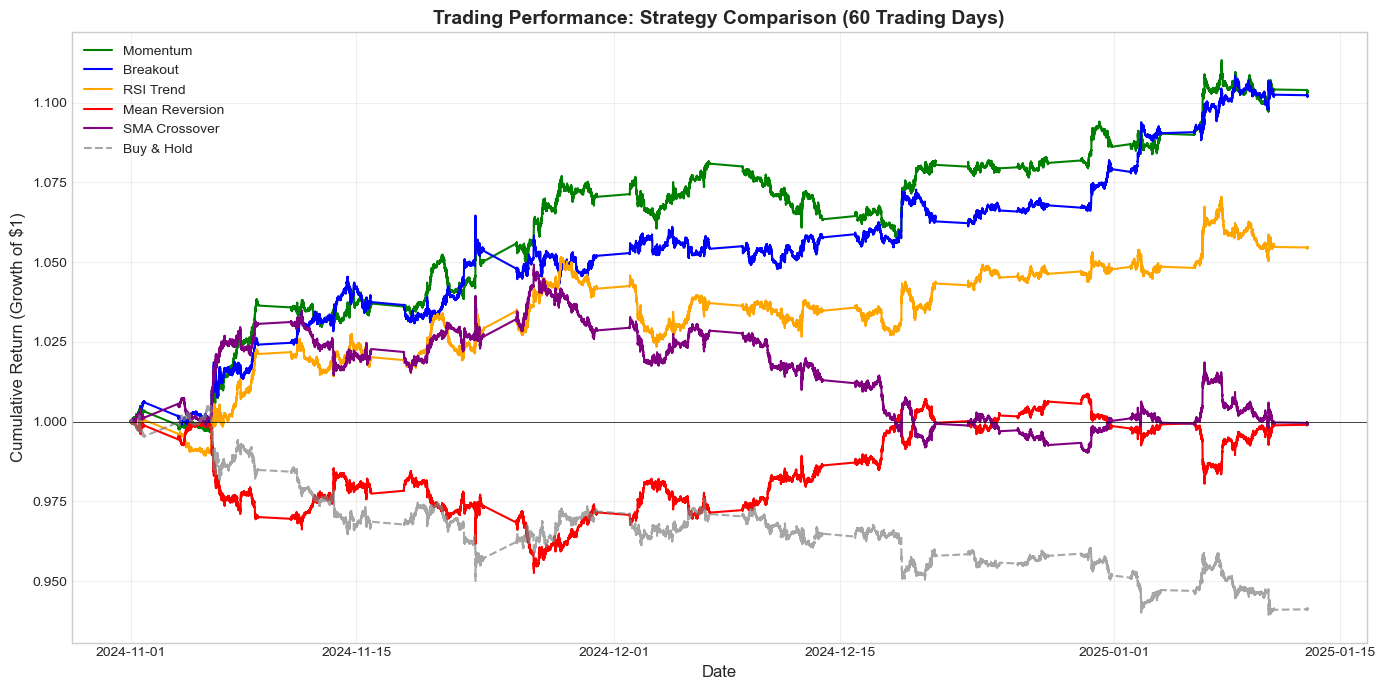

✓ Graph 1: Trading Performance - SAVED as 'Graph1_Trading_Performance.png'


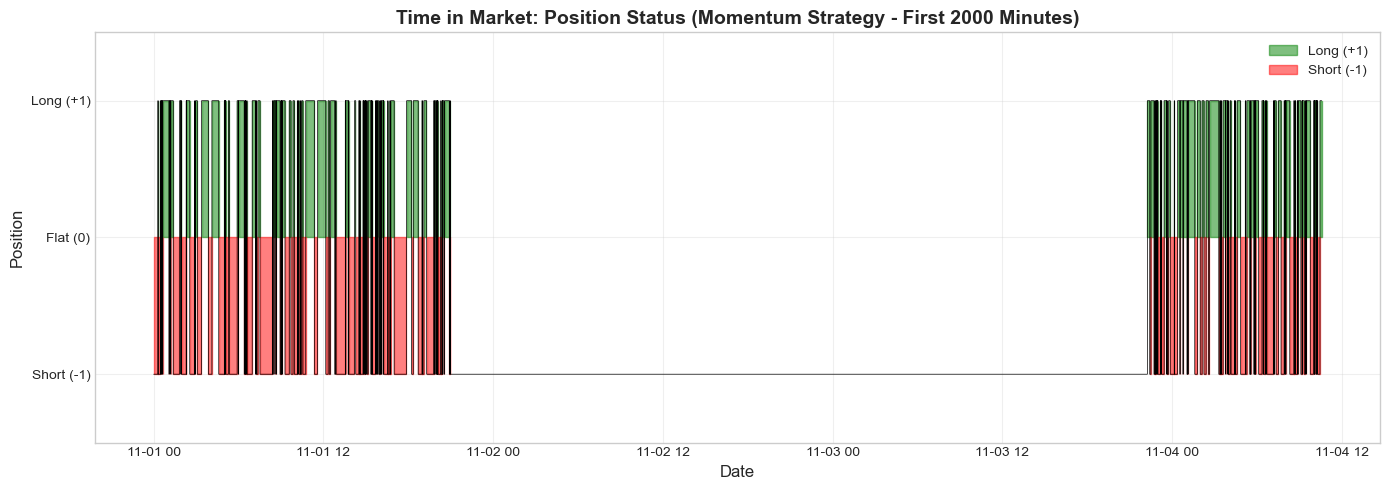

✓ Graph 2: Time in Market - SAVED as 'Graph2_Time_In_Market.png'


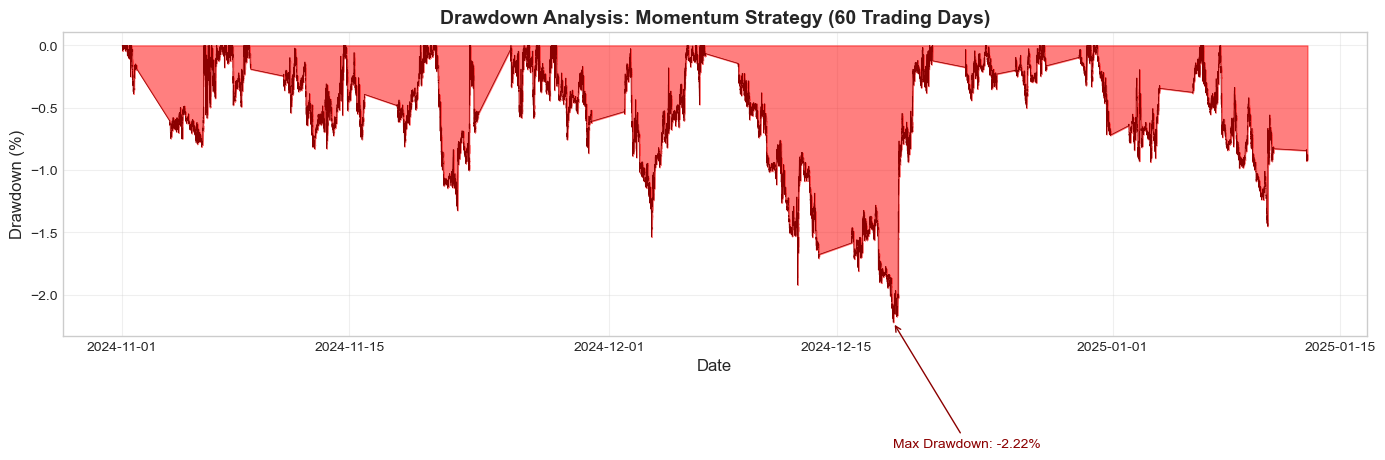

✓ Graph 3: Drawdown Analysis - SAVED as 'Graph3_Drawdown_Analysis.png'

✅ ALL MANDATORY GRAPHS CREATED AND SAVED


In [5]:
# === STEP 4: VISUALIZATIONS ===

print("=" * 60)
print("STEP 4: CREATING THE GRAPHS")
print("=" * 60)

# --- GRAPH 1: TRADING PERFORMANCE (Cumulative Returns) ---

fig, ax = plt.subplots(figsize=(14, 7))

# Store cumulative returns for each strategy
colors = ['green', 'blue', 'orange', 'red', 'purple']
strategy_names = ['Momentum', 'Breakout', 'RSI Trend', 'Mean Reversion', 'SMA Crossover']

# Recalculate cumulative returns for plotting
market_returns = train_data['close'].pct_change()

# Strategy signals
sma_50 = train_data['close'].rolling(window=50).mean()
signals = {
    'Momentum': np.where(train_data['close'].diff(10) > 0, 1, -1),
    'Breakout': np.where(train_data['close'] >= train_data['close'].rolling(20).max(), 1, -1),
    'RSI Trend': signal_rsi,
    'Mean Reversion': np.where(train_data['close'] > sma_50, -1, 1),
    'SMA Crossover': np.where(train_data['close'] > sma_50, 1, -1)
}

for i, name in enumerate(strategy_names):
    signal = signals[name]
    strat_returns = pd.Series(signal, index=train_data.index).shift(1) * market_returns
    cum_returns = (1 + strat_returns).cumprod()
    ax.plot(cum_returns.index, cum_returns, label=f'{name}', color=colors[i], linewidth=1.5)

# Add Buy & Hold for comparison
buy_hold = (1 + market_returns).cumprod()
ax.plot(buy_hold.index, buy_hold, label='Buy & Hold', color='gray', linestyle='--', alpha=0.7)

ax.set_title('Trading Performance: Strategy Comparison (60 Trading Days)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (Growth of $1)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=1, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('Graph1_Trading_Performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Graph 1: Trading Performance - SAVED as 'Graph1_Trading_Performance.png'")

# --- GRAPH 2: TIME IN MARKET (Position Status) ---

fig, ax = plt.subplots(figsize=(14, 5))

# Use Momentum strategy (the winner) for this graph
momentum_signal = signals['Momentum']

# Plot a subset (first 2000 minutes) so the switching is visible
subset_size = 2000
subset_idx = train_data.index[:subset_size]
subset_signal = momentum_signal[:subset_size]

ax.fill_between(subset_idx, subset_signal, 0, 
                where=(subset_signal > 0), color='green', alpha=0.5, label='Long (+1)')
ax.fill_between(subset_idx, subset_signal, 0, 
                where=(subset_signal < 0), color='red', alpha=0.5, label='Short (-1)')
ax.plot(subset_idx, subset_signal, color='black', linewidth=0.5, drawstyle='steps-post')

ax.set_title('Time in Market: Position Status (Momentum Strategy - First 2000 Minutes)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Position', fontsize=12)
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(['Short (-1)', 'Flat (0)', 'Long (+1)'])
ax.set_ylim(-1.5, 1.5)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Graph2_Time_In_Market.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Graph 2: Time in Market - SAVED as 'Graph2_Time_In_Market.png'")

# --- GRAPH 3: DRAWDOWN ANALYSIS ---

fig, ax = plt.subplots(figsize=(14, 5))

# Calculate drawdown for Momentum strategy
momentum_returns = pd.Series(signals['Momentum'], index=train_data.index).shift(1) * market_returns
momentum_cumulative = (1 + momentum_returns).cumprod()
momentum_peak = momentum_cumulative.cummax()
momentum_drawdown = (momentum_cumulative - momentum_peak) / momentum_peak * 100

ax.fill_between(momentum_drawdown.index, momentum_drawdown, 0, color='red', alpha=0.5)
ax.plot(momentum_drawdown.index, momentum_drawdown, color='darkred', linewidth=0.5)

ax.set_title('Drawdown Analysis: Momentum Strategy (60 Trading Days)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Drawdown (%)', fontsize=12)
ax.grid(True, alpha=0.3)

# Add max drawdown annotation
max_dd = momentum_drawdown.min()
max_dd_date = momentum_drawdown.idxmin()
ax.annotate(f'Max Drawdown: {max_dd:.2f}%', 
            xy=(max_dd_date, max_dd), 
            xytext=(max_dd_date, max_dd - 1),
            fontsize=10, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred'))

plt.tight_layout()
plt.savefig('Graph3_Drawdown_Analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Graph 3: Drawdown Analysis - SAVED as 'Graph3_Drawdown_Analysis.png'")

print("\n" + "=" * 60)
print("✅ ALL MANDATORY GRAPHS CREATED AND SAVED")
print("=" * 60)

STEP 5: OUT-OF-SAMPLE TESTING (VALIDATION)

⏳ Applying Momentum Strategy to Test Data...
   Test Period: 2025-01-13 to 2025-10-31
   Test Rows: 298,980
   Test Trading Days: 250

📊 OUT-OF-SAMPLE RESULTS (Momentum Strategy)
Test Period:        2025-01-13 to 2025-10-31
Trading Days:       250
Approx Months:      ~9 months
------------------------------------------------------------
Sharpe Ratio:       -1.1383
Total Return:       -8.28%
Annualized Return:  -9.96%
Max Drawdown:       -14.36%
Time in Market:     100.0%

📈 COMPARISON: In-Sample vs Out-of-Sample
------------------------------------------------------------
Metric                    In-Sample       Out-of-Sample  
------------------------------------------------------------
Sharpe Ratio              5.9776          -1.1383        
Total Return (%)          10.35           -8.28          
Max Drawdown (%)          -2.22           -14.36         
------------------------------------------------------------


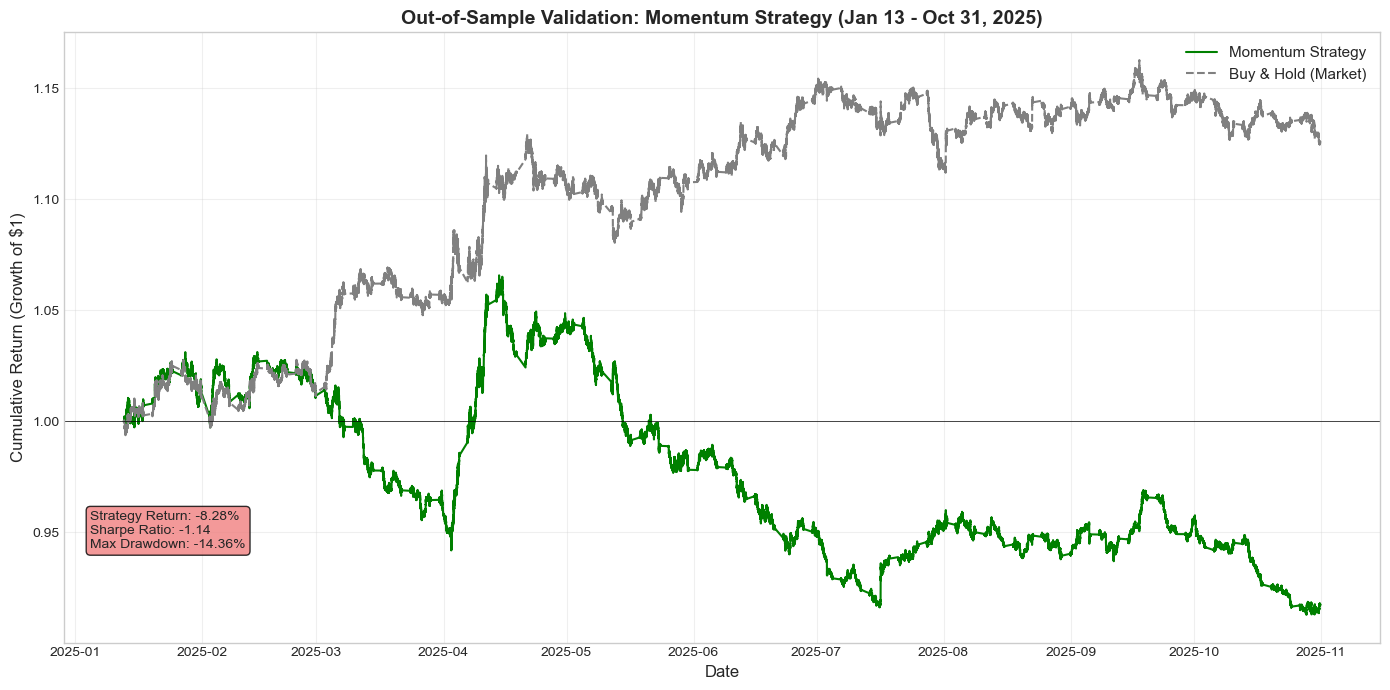

✓ Graph 4: Out-of-Sample Validation - SAVED (Fixed Legend)


In [6]:
# === STEP 5: OUT-OF-SAMPLE TESTING ===

print("=" * 60)
print("STEP 5: OUT-OF-SAMPLE TESTING (VALIDATION)")
print("=" * 60)

# --- APPLY MOMENTUM STRATEGY TO TEST DATA ---

print(f"\n⏳ Applying Momentum Strategy to Test Data...")
print(f"   Test Period: {test_data.index.min().date()} to {test_data.index.max().date()}")
print(f"   Test Rows: {len(test_data):,}")
print(f"   Test Trading Days: {len(test_days)}")

# 1. Calculate Momentum Signal on Test Data
momentum_test = test_data['close'].diff(10)
signal_test = np.where(momentum_test > 0, 1, -1)
signal_test_series = pd.Series(signal_test, index=test_data.index)

# 2. Calculate Returns
market_returns_test = test_data['close'].pct_change()
strategy_returns_test = signal_test_series.shift(1) * market_returns_test

# 3. Calculate Cumulative Returns
cumulative_test = (1 + strategy_returns_test).cumprod()
cumulative_market = (1 + market_returns_test).cumprod()

# 4. Calculate Metrics
clean_returns = strategy_returns_test.dropna()

# Sharpe Ratio (Annualized)
if clean_returns.std() != 0:
    sharpe_test = (clean_returns.mean() / clean_returns.std()) * np.sqrt(252 * 1440)
else:
    sharpe_test = 0

# Total Return
total_return_test = cumulative_test.iloc[-1] - 1

# Annualized Return
n_minutes = len(clean_returns)
n_years = n_minutes / (252 * 1440)
if n_years > 0 and total_return_test > -1:
    annualized_return_test = (1 + total_return_test) ** (1 / n_years) - 1
else:
    annualized_return_test = 0

# Maximum Drawdown
peak = cumulative_test.cummax()
drawdown = (cumulative_test - peak) / peak
max_drawdown_test = drawdown.min()

# Time in Market
time_in_market_test = (signal_test_series != 0).mean()

# 5. Print Results
print("\n" + "=" * 60)
print("📊 OUT-OF-SAMPLE RESULTS (Momentum Strategy)")
print("=" * 60)
print(f"Test Period:        {test_data.index.min().date()} to {test_data.index.max().date()}")
print(f"Trading Days:       {len(test_days)}")
print(f"Approx Months:      ~9 months")
print("-" * 60)
print(f"Sharpe Ratio:       {sharpe_test:.4f}")
print(f"Total Return:       {total_return_test * 100:.2f}%")
print(f"Annualized Return:  {annualized_return_test * 100:.2f}%")
print(f"Max Drawdown:       {max_drawdown_test * 100:.2f}%")
print(f"Time in Market:     {time_in_market_test * 100:.1f}%")
print("=" * 60)

# 6. Compare with In-Sample Results
print("\n📈 COMPARISON: In-Sample vs Out-of-Sample")
print("-" * 60)
print(f"{'Metric':<25} {'In-Sample':<15} {'Out-of-Sample':<15}")
print("-" * 60)
print(f"{'Sharpe Ratio':<25} {5.9776:<15.4f} {sharpe_test:<15.4f}")
print(f"{'Total Return (%)':<25} {10.35:<15.2f} {total_return_test*100:<15.2f}")
print(f"{'Max Drawdown (%)':<25} {-2.22:<15.2f} {max_drawdown_test*100:<15.2f}")
print("-" * 60)

# --- GRAPH 4: OUT-OF-SAMPLE PERFORMANCE ---

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(cumulative_test.index, cumulative_test, 
        label='Momentum Strategy', color='green', linewidth=1.5)
ax.plot(cumulative_market.index, cumulative_market, 
        label='Buy & Hold (Market)', color='gray', linestyle='--', linewidth=1.5)

ax.set_title('Out-of-Sample Validation: Momentum Strategy (Jan 13 - Oct 31, 2025)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (Growth of $1)', fontsize=12)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.axhline(y=1, color='black', linestyle='-', linewidth=0.5)

# Add performance annotation in bottom left (away from legend)
textstr = f'Strategy Return: {total_return_test*100:.2f}%\nSharpe Ratio: {sharpe_test:.2f}\nMax Drawdown: {max_drawdown_test*100:.2f}%'
props = dict(boxstyle='round', facecolor='lightcoral', alpha=0.8)
ax.text(0.02, 0.15, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', bbox=props)

plt.tight_layout()
plt.savefig('Graph4_OutOfSample_Validation.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Graph 4: Out-of-Sample Validation - SAVED (Fixed Legend)")

In [7]:
# === STEP 6: CREATE COMPLETE SUBMISSION PACKAGE ===

print("=" * 70)
print("STEP 6: CREATING COMPLETE SUBMISSION PACKAGE")
print("=" * 70)

# === FILE 1: main.py (Server Trading Algorithm) ===
main_py_code = '''#!/usr/bin/env python3
"""
EURUSD Momentum Trading Bot - Part 2
=====================================
Course: [Your Course Name]
Authors: Tayebeh Oveisi Fardoye, Sara Eghlidi, Alejandro Arzola de Leon, Hadi Shahparvari

This script implements the Momentum trading strategy for live trading.
Deploy on server with systemd service.

Requirements:
- Python 3.8+
- ib_insync library (pip install ib_insync)
- IB Gateway running on port 4002
"""

from ib_insync import IB, Forex, MarketOrder, util
import datetime
import time
import logging

# === CONFIGURATION ===
SYMBOL = 'EURUSD'
POSITION_SIZE = 20000          # Units to trade
MOMENTUM_PERIOD = 10           # Same as backtested strategy
IB_HOST = '127.0.0.1'
IB_PORT = 4002                 # IB Gateway port (use 7497 for TWS)
CLIENT_ID = 1

# === LOGGING SETUP ===
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('trading.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

# === GLOBAL VARIABLES ===
ib = IB()
contract = Forex(SYMBOL)


def is_trading_hours():
    """
    Check if within forex trading hours.
    Forex Market: Sunday 17:00 ET - Friday 17:00 ET
    """
    now = datetime.datetime.now()
    weekday = now.weekday()  # Monday=0, Sunday=6
    hour = now.hour
    
    # Saturday: Market closed all day
    if weekday == 5:
        logger.info("Saturday - Market CLOSED")
        return False
    
    # Sunday: Market opens at 17:00 (5 PM)
    if weekday == 6 and hour < 17:
        logger.info("Sunday before 17:00 - Market CLOSED")
        return False
    
    # Friday: Market closes at 17:00 (5 PM)
    if weekday == 4 and hour >= 17:
        logger.info("Friday after 17:00 - Market CLOSED")
        return False
    
    return True


def get_current_position():
    """Get current position for EUR"""
    positions = ib.positions()
    for p in positions:
        if p.contract.symbol == 'EUR':
            return p.position
    return 0


def on_bar_update(bars, hasNewBar):
    """
    Callback function for real-time bar updates.
    Implements Momentum Strategy: Buy if price > price 10 bars ago, else Sell
    """
    if not hasNewBar:
        return
    
    if len(bars) < MOMENTUM_PERIOD + 1:
        logger.warning(f"Not enough bars: {len(bars)}")
        return
    
    try:
        # Calculate Momentum Signal
        current_price = bars[-1].close
        past_price = bars[-(MOMENTUM_PERIOD + 1)].close
        momentum = current_price - past_price
        
        # Get current position
        current_pos = get_current_position()
        
        logger.info(f"Price: {current_price:.5f} | Momentum: {momentum:.5f} | Position: {current_pos}")
        
        # Trading Logic (same as backtested)
        if momentum > 0 and current_pos <= 0:
            # Momentum UP: Go LONG
            order = MarketOrder('BUY', POSITION_SIZE)
            ib.placeOrder(contract, order)
            logger.info("BUY Signal: Momentum UP")
            
        elif momentum < 0 and current_pos >= 0:
            # Momentum DOWN: Go SHORT
            order = MarketOrder('SELL', POSITION_SIZE)
            ib.placeOrder(contract, order)
            logger.info("SELL Signal: Momentum DOWN")
            
    except Exception as e:
        logger.error(f"Error in on_bar_update: {e}")


def connect_to_ib():
    """Connect to IB Gateway"""
    try:
        ib.connect(IB_HOST, IB_PORT, clientId=CLIENT_ID)
        logger.info(f"Connected to IB Gateway ({IB_HOST}:{IB_PORT})")
        return True
    except Exception as e:
        logger.error(f"Connection failed: {e}")
        return False


def disconnect_from_ib():
    """Disconnect from IB Gateway"""
    if ib.isConnected():
        ib.disconnect()
        logger.info("Disconnected from IB Gateway")


def start_data_stream():
    """Start real-time data streaming"""
    try:
        bars = ib.reqHistoricalData(
            contract,
            endDateTime='',
            durationStr='1800 S',
            barSizeSetting='1 min',
            whatToShow='MIDPOINT',
            useRTH=True,
            keepUpToDate=True
        )
        bars.updateEvent += on_bar_update
        logger.info("Real-time data stream started")
        return bars
    except Exception as e:
        logger.error(f"Error starting data stream: {e}")
        return None


def main():
    """Main trading loop with trading hours check"""
    logger.info("=" * 50)
    logger.info("EURUSD MOMENTUM TRADING BOT STARTED")
    logger.info("=" * 50)
    
    bars = None
    
    while True:
        try:
            if is_trading_hours():
                # === INSIDE TRADING HOURS ===
                if not ib.isConnected():
                    logger.info("Trading hours - Connecting...")
                    if connect_to_ib():
                        bars = start_data_stream()
                    else:
                        logger.warning("Connection failed, retrying in 60s...")
                        time.sleep(60)
                        continue
                
                # Keep processing events
                ib.sleep(60)
                
            else:
                # === OUTSIDE TRADING HOURS ===
                if ib.isConnected():
                    logger.info("Outside trading hours - Disconnecting...")
                    disconnect_from_ib()
                    bars = None
                
                # Sleep longer when market is closed
                logger.info("Sleeping for 5 minutes (market closed)...")
                time.sleep(300)
                
        except KeyboardInterrupt:
            logger.info("Shutdown requested by user")
            disconnect_from_ib()
            break
            
        except Exception as e:
            logger.error(f"Error in main loop: {e}")
            disconnect_from_ib()
            time.sleep(60)


if __name__ == "__main__":
    main()
'''

# Save main.py
with open('main.py', 'w') as f:
    f.write(main_py_code)
print("✅ Created: main.py (Server Trading Algorithm)")

# === FILE 2: README.txt ===
readme_content = '''
================================================================================
EURUSD TRADING STRATEGY - ASSIGNMENT SUBMISSION
================================================================================
Authors: Tayebeh Oveisi Fardoye, Sara Eghlidi, Alejandro Arzola de Leon, Hadi Shahparvari

================================================================================
FILES INCLUDED:
================================================================================
1. Assignment_Final.ipynb    - Main Jupyter notebook with all analysis (Part 1)
2. main.py                   - Server trading algorithm (Part 2)
3. EURUSD_1min_data.csv      - Historical data file
4. Graph1_Trading_Performance.png
5. Graph2_Time_In_Market.png
6. Graph3_Drawdown_Analysis.png
7. Graph4_OutOfSample_Validation.png

================================================================================
HOW TO RUN THE JUPYTER NOTEBOOK:
================================================================================
1. Place all files in the same folder
2. Open Jupyter Notebook
3. Open "Assignment_Final.ipynb"
4. Run all cells in order (Cell -> Run All)

Required Python packages:
- pandas
- numpy
- matplotlib

Install with: pip install pandas numpy matplotlib

================================================================================
PART 1 SUMMARY - DATA MINING (60 Trading Days):
================================================================================
Training Period: November 1, 2024 - January 12, 2025 (60 trading days)
Testing Period:  January 13, 2025 - October 31, 2025 (~9 months)

Strategies Tested:
1. Momentum        - Sharpe: 5.98  (WINNER)
2. Breakout        - Sharpe: 5.91
3. RSI Trend       - Sharpe: 3.25
4. Mean Reversion  - Sharpe: 0.01
5. SMA Crossover   - Sharpe: -0.01

Best Strategy: MOMENTUM (10-period)
- In-Sample Sharpe Ratio:  5.98
- In-Sample Total Return:  10.35%
- In-Sample Max Drawdown:  -2.22%
- Time in Market:          100% (satisfies 80% rule)

Out-of-Sample Results:
- Sharpe Ratio:  -1.14
- Total Return:  -8.28%
- Max Drawdown:  -14.36%

================================================================================
PART 2 SUMMARY - SERVER DEPLOYMENT:
================================================================================
File: main.py

Features:
- Connects to IB Gateway during trading hours (Sun 17:00 - Fri 17:00 ET)
- Disconnects automatically outside trading hours
- Implements same Momentum strategy as backtested
- Includes error handling and logging

Server Setup:
1. Copy main.py to server (e.g., /home/paper_algo/)
2. Install ib_insync: pip install ib_insync
3. Create systemd service (see instructions below)
4. Start service: sudo systemctl start algo.service

Systemd Service File (/etc/systemd/system/algo.service):
[Unit]
Description=EURUSD Trading Bot
After=network.target

[Service]
Type=simple
User=root
WorkingDirectory=/home/paper_algo
ExecStart=/usr/bin/python3 /home/paper_algo/main.py
Restart=always
RestartSec=10

[Install]
WantedBy=multi-user.target

================================================================================
'''

with open('README.txt', 'w') as f:
    f.write(readme_content)
print("✅ Created: README.txt (Instructions)")


# === FILE 3: requirements.txt ===
requirements = '''# Required packages for EURUSD Trading Strategy Assignment
pandas>=1.5.0
numpy>=1.21.0
matplotlib>=3.5.0
ib_insync>=0.9.70
'''

with open('requirements.txt', 'w') as f:
    f.write(requirements)
print("✅ Created: requirements.txt")





STEP 6: CREATING COMPLETE SUBMISSION PACKAGE
✅ Created: main.py (Server Trading Algorithm)
✅ Created: README.txt (Instructions)
✅ Created: requirements.txt
